In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("lahore_flats_feature_engineered.csv")

In [3]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'built_year', 'link',
       'parking_spaces', 'floor', 'floors_in_building', 'price', 'area',
       'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score'],
      dtype='object')

In [5]:
df.describe()

,property_id,bedrooms,baths,built_year,price,area,area_sqft,servant_quarters,kitchens,store_rooms,...,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score
count,3118.0,3021.000000,3089.000000,2271.000000,3118.000000,3118.000000,3118.000000,1732.000000,2370.000000,1760.000000,...,3118.000000,3118.000000,3118.000000,3118.000000,3118.000000,3118.000000,3118.000000,3118.000000,3118.000000,3118.000000
mean,1.0,2.180735,2.293299,2023.054161,2.210902,6.880019,1871.365234,1.125866,1.153165,1.095455,...,0.749840,0.705581,0.652983,0.672547,0.683451,0.585311,0.585632,0.559333,141.720013,37.723541
std,0.0,1.097456,1.358893,5.258864,1.653603,34.807709,9467.696829,0.396811,0.449849,0.330352,...,0.433175,0.455854,0.476098,0.469360,0.465204,0.492747,0.492692,0.496547,46.583240,14.808733
min,1.0,1.000000,1.000000,1982.000000,0.250000,0.400000,108.800000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.0,1.000000,1.000000,2022.000000,0.765400,2.200000,598.400000,1.000000,1.000000,1.000000,...,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,121.000000,31.000000
50%,1.0,2.000000,2.000000,2025.000000,1.600000,4.100000,1115.200000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,158.000000,47.000000
75%,1.0,3.000000,3.000000,2025.000000,3.500000,10.000000,2720.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,176.000000,49.000000
max,1.0,9.000000,8.000000,2030.000000,11.950000,1200.000000,326400.000000,6.000000,11.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,187.000000,49.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3118 entries, 0 to 3117
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   property_id             3118 non-null   int64  
 1   society                 3118 non-null   object 
 2   bedrooms                3021 non-null   float64
 3   baths                   3089 non-null   float64
 4   built_year              2271 non-null   float64
 5   link                    3118 non-null   object 
 6   parking_spaces          2683 non-null   object 
 7   floor                   1976 non-null   object 
 8   floors_in_building      2048 non-null   object 
 9   price                   3118 non-null   float64
 10  area                    3118 non-null   float64
 11  area_sqft               3118 non-null   float64
 12  servant_quarters        1732 non-null   float64
 13  kitchens                2370 non-null   float64
 14  store_rooms             1760 non-null   

In [7]:
num_cols = ["parking_spaces", "floor", "floors_in_building"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


In [9]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'built_year', 'link',
       'floors_in_building', 'price', 'area', 'area_sqft', 'servant_quarters',
       'kitchens', 'store_rooms', 'price_per_sqft', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score'],
      dtype='object')

In [10]:
df.shape

(3118, 28)

In [11]:
df.head()

,property_id,society,bedrooms,baths,built_year,link,parking_spaces,floor,floors_in_building,price,...,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score
0,1,Askari,4.0,4.0,2026.0,https://www.zameen.com/Property/askari_askari_...,2.0,3.0,9.0,4.55,...,1,1,1,1,1,0,0,0,135.0,37
1,1,Askari,4.0,5.0,2025.0,https://www.zameen.com/Property/askari_10_aska...,1.0,3.0,10.0,4.50,...,0,0,1,1,0,0,0,1,150.0,31
2,1,Askari,3.0,4.0,2024.0,https://www.zameen.com/Property/askari_11_aska...,4.0,NaN,NaN,3.55,...,1,1,1,1,1,1,1,1,156.0,49
3,1,Askari,4.0,4.0,2023.0,https://www.zameen.com/Property/askari_askari_...,2.0,NaN,NaN,4.45,...,0,0,1,0,0,0,0,1,125.0,18
4,1,Askari,4.0,5.0,2025.0,https://www.zameen.com/Property/askari_10_aska...,NaN,3.0,10.0,4.65,...,0,0,1,1,0,0,0,1,100.0,18


In [14]:
df.shape

(3118, 28)

In [15]:
thresh = len(df) * 0.5
drop_cols = df.columns[df.isna().sum() > thresh]
df = df.drop(columns=drop_cols)


In [16]:
df.shape

(3118, 26)

In [17]:
pd.set_option("display.max_columns", None)
df.head()


,property_id,society,bedrooms,baths,built_year,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score
0,1,Askari,4.0,4.0,2026.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37
1,1,Askari,4.0,5.0,2025.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,NaN,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31
2,1,Askari,3.0,4.0,2024.0,https://www.zameen.com/Property/askari_11_aska...,NaN,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49
3,1,Askari,4.0,4.0,2023.0,https://www.zameen.com/Property/askari_askari_...,NaN,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18
4,1,Askari,4.0,5.0,2025.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18


## Univarient Analysis
- Col dist
- outliers
- missing val

## society                 

In [18]:
df['society'].value_counts().shape

(71,)

In [20]:
dict(df['society'].value_counts())

{'Askari': np.int64(955),
 'Bahria Town': np.int64(566),
 'Gulberg': np.int64(474),
 'DHA Defence': np.int64(238),
 'Raiwind Road': np.int64(212),
 'Bahria Orchard': np.int64(163),
 'Main Canal Bank Road': np.int64(69),
 'Johar Town': np.int64(60),
 'Defence Road': np.int64(34),
 'Model Town': np.int64(24),
 'Land Breeze Housing Society': np.int64(21),
 'Shanghai Road': np.int64(19),
 'Abdul Sattar Edhi Road': np.int64(17),
 'Khayaban-e-Amin': np.int64(16),
 'Bahria Nasheman': np.int64(16),
 'Izmir Town': np.int64(16),
 'Paragon City': np.int64(13),
 'Garden Town': np.int64(13),
 'Jubilee Town': np.int64(13),
 'Sukh Chayn Gardens': np.int64(11),
 'Allama Iqbal Town': np.int64(10),
 'Jail Road': np.int64(10),
 'Ferozepur Road': np.int64(9),
 'Lawrence Road': np.int64(9),
 'Wapda Town': np.int64(8),
 'Shah Jamal': np.int64(8),
 'LDA Avenue': np.int64(8),
 'Punjab University Employees Society': np.int64(7),
 'Ichhra': np.int64(6),
 'Lake City Meadows': np.int64(6),
 'Icon Valley': np.int6

In [21]:
society_counts = df["society"].value_counts()

frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}

frequency_bins


{'Very High (>100)': np.int64(6),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(14),
 'Low (2-9)': np.int64(30),
 'Very Low (1)': np.int64(19)}

<Axes: xlabel='society'>

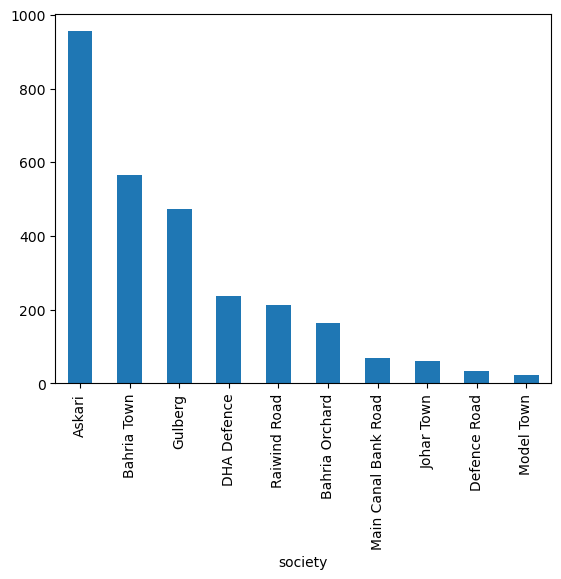

In [22]:
df["society"].value_counts().head(10).plot(kind='bar')

In [23]:
df['society'].isnull().sum()

np.int64(0)

**Observability**
- 71 societies/areas  
- Frequency bins:  
  - Very High (>100): 6  
  - High (50–100): 2  
  - Average (10–49): 14  
  - Low (2–9): 30  
  - Very Low (1): 19  
- Missing values in `society`: 0


## Price

In [24]:
df['price'].isnull().sum()

np.int64(0)

In [25]:
df['price'].value_counts()

price
0.7500    65
0.6500    59
0.6000    57
2.8500    54
0.8000    54
          ..
0.6092     1
0.7835     1
0.5475     1
0.2925     1
0.4499     1
Name: count, Length: 539, dtype: int64

In [26]:
df['price'].describe()

count    3118.000000
mean        2.210902
std         1.653603
min         0.250000
25%         0.765400
50%         1.600000
75%         3.500000
max        11.950000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

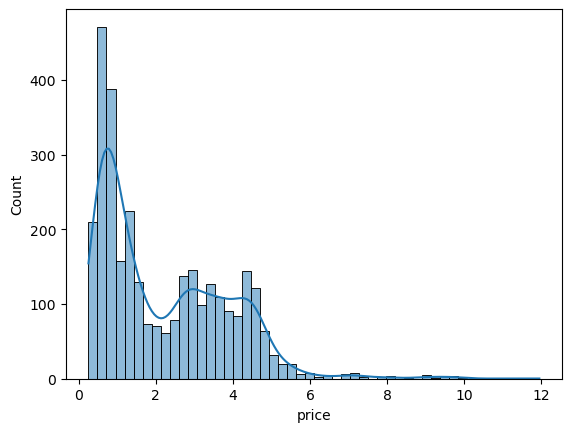

In [28]:
sns.histplot(df["price"], kde=True, bins=50)

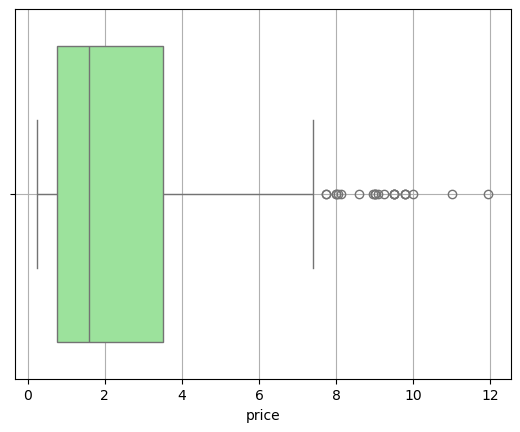

In [29]:
sns.boxplot(x=df["price"], color="lightgreen")
plt.grid()


**Descriptive Statistics (df['price'].describe())**
- Count: 3,118 non‑missing price entries  
- Mean: ~2.21 crore  
- Median (50%): 1.60 crore  
- Std Dev: ~1.65  
- Range: 0.25 to 11.95 crore  
- IQR: 0.765 to 3.50 crore  

**Visualizations**
- Histogram: Right‑skewed; most prices are below ~4–5 crore with a long tail.  
- Box Plot: Several high‑end outliers, extending up to ~12 crore.  

**Missing Values**
- Missing count: 0


In [30]:
# Skewness and Kurtosis
skewness = df["price"].skew() # how much your data skwed 
kurtosis = df["price"].kurt() # how much haviness in tail
print(skewness, kurtosis)


1.020473306809174 1.3281786707466297


- **Skewness:** ~1.02 → positively skewed (right‑tailed); most prices are lower with a few high‑priced outliers.  
- **Kurtosis:** ~1.33 → heavier tails than normal, indicating some outliers.  


In [31]:
# Quantile Analysis
quantiles = df["price"].quantile([0.01, 0.05, 0.95, 0.99])
quantiles


0.01    0.3200
0.05    0.4500
0.95    4.8000
0.99    7.0915
Name: price, dtype: float64

**Quantile Analysis**
- 1% Quantile: ~0.32 crore  
- 5% Quantile: ~0.45 crore  
- 95% Quantile: ~4.80 crore  
- 99% Quantile: ~7.09 crore (only 1% are higher)


In [32]:
# Identify potential outliers using IQR method
Q1 = df["price"].describe()["25%"]
Q3 = df["price"].describe()["75%"]
IQR = Q3 - Q1
IQR


np.float64(2.7346)

In [33]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)


-3.3364999999999996 7.6019


In [34]:
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
outliers.shape

(23, 26)

In [35]:
outliers["price"].describe()

count    23.000000
mean      9.170000
std       1.022879
min       7.740000
25%       8.365000
50%       9.100000
75%       9.650000
max      11.950000
Name: price, dtype: float64

**Outliers Analysis (IQR Method)**
- Bounds: lower = ‑3.34, upper = 7.60  
- Outliers found: 23 properties  
- Outlier prices: mean ~9.17 crore, range 7.74 to 11.95 crore


<Axes: xlabel='price'>

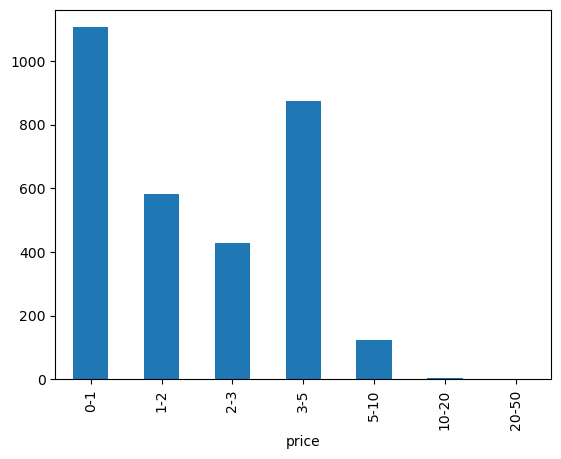

In [36]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df["price"], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind="bar")

- Most listings fall in the **0–1** and **3–5 crore** bins, with moderate counts in **1–2** and **2–3**.  
- There’s a sharp drop after **5 crore**; very few listings appear above **10 crore**.  


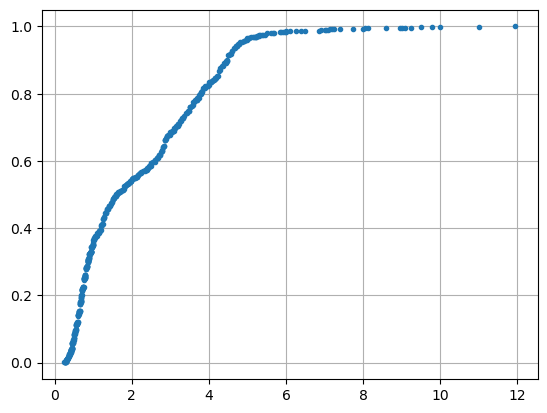

In [37]:
# ecdf plot
ecdf = df["price"].value_counts().sort_index().cumsum() / len(df["price"])
plt.plot(ecdf.index, ecdf, marker=".", linestyle="none")
plt.grid()


In [38]:
df.shape

(3118, 26)

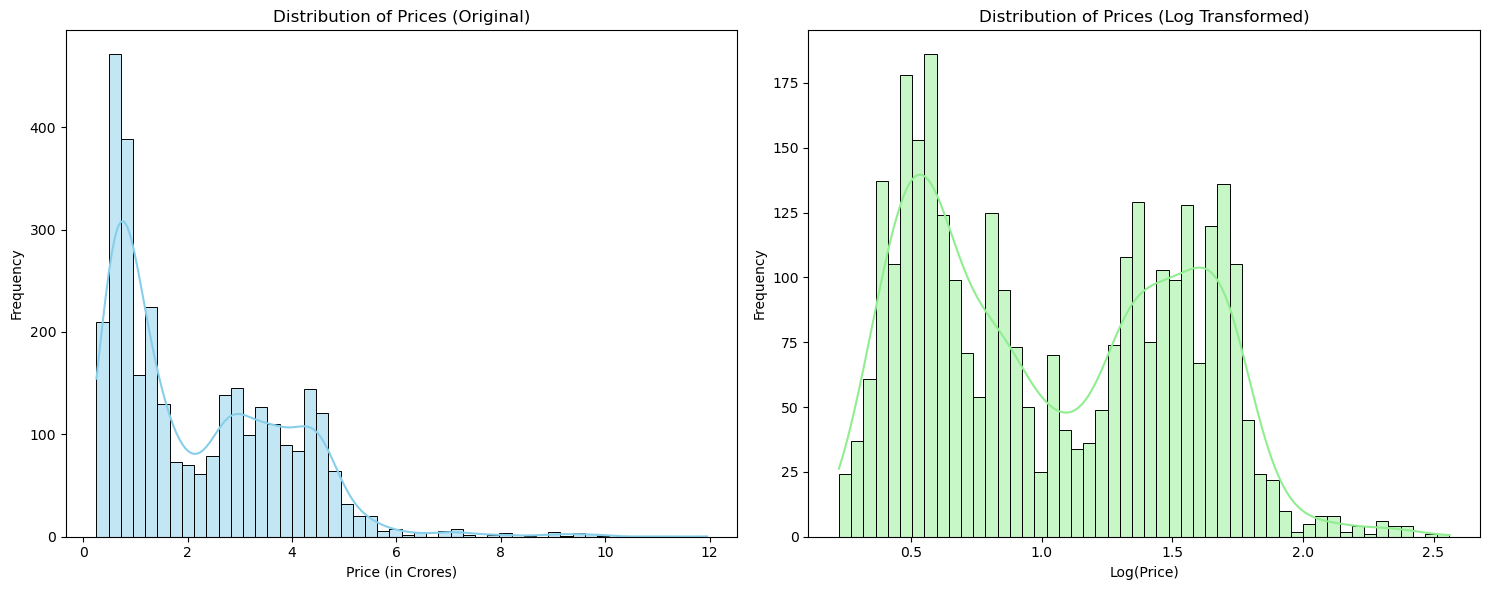

In [39]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df["price"], kde=True, bins=50, color="skyblue")
plt.title("Distribution of Prices (Original)")
plt.xlabel("Price (in Crores)")
plt.ylabel("Frequency")

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["price"]), kde=True, bins=50, color="lightgreen")
plt.title("Distribution of Prices (Log Transformed)")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


`np.log1p(x)` computes `ln(1 + x)`, which is more numerically stable for values near 0.  
It’s useful for transforming the price column because it safely handles zero values.  
To reverse it, use `np.expm1(y)` which computes `e^y - 1`.


In [40]:
# Skewness & kurtosis (log-transformed)
skewness = np.log1p(df["price"]).skew()
kurtosis = np.log1p(df["price"]).kurt()
print(skewness, kurtosis)


0.2152712048944141 -1.2161964274903074


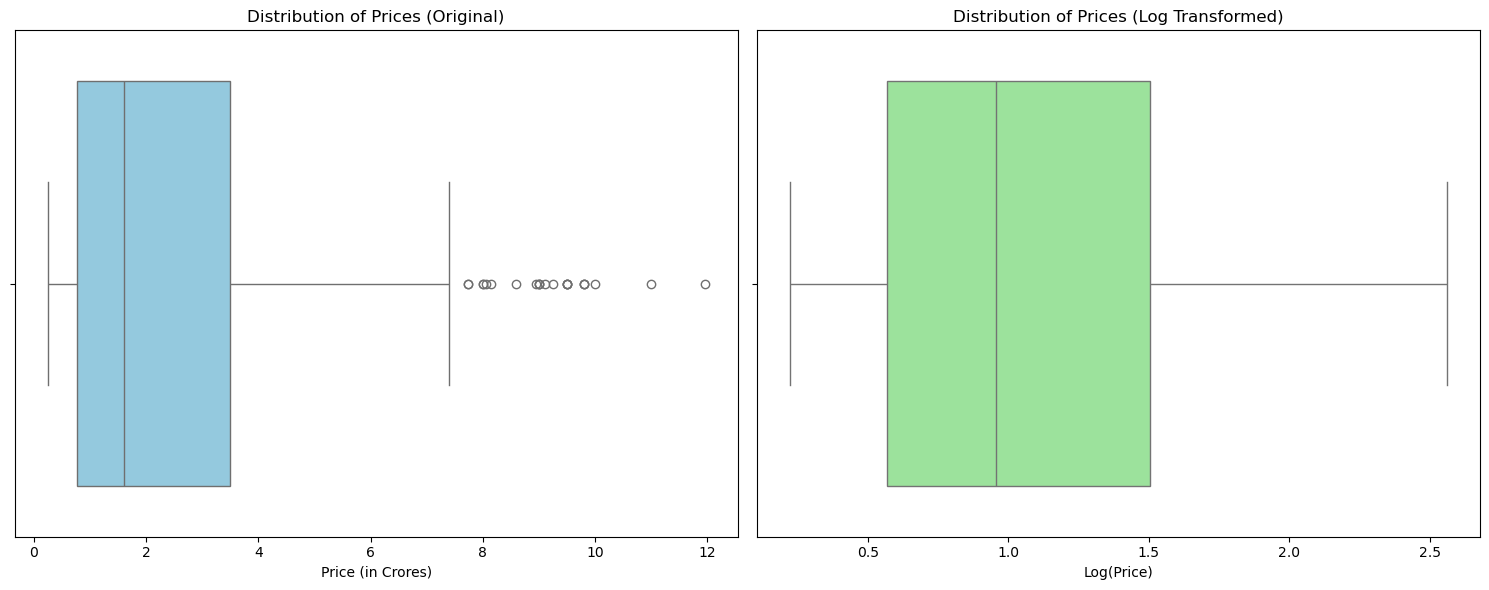

In [41]:
plt.figure(figsize=(15, 6))

# Box plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df["price"], color="skyblue")
plt.title("Distribution of Prices (Original)")
plt.xlabel("Price (in Crores)")

# Box plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df["price"]), color="lightgreen")
plt.title("Distribution of Prices (Log Transformed)")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()


## price per sqft

In [42]:
df["price_per_sqft"].isnull().sum()

np.int64(0)

In [43]:
df["price_per_sqft"].describe()

count      3118.000000
mean      15830.118316
std        9521.850924
min          27.941176
25%       10588.235294
50%       13166.791753
75%       17129.010695
max      116421.568627
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

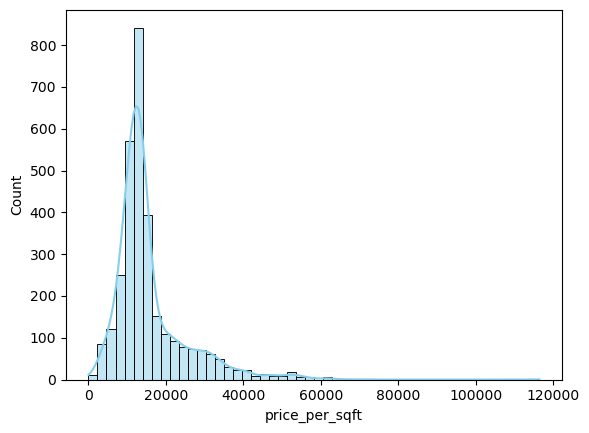

In [44]:
sns.histplot(df["price_per_sqft"], bins=50, color="skyblue", kde=True)


<Axes: xlabel='price_per_sqft'>

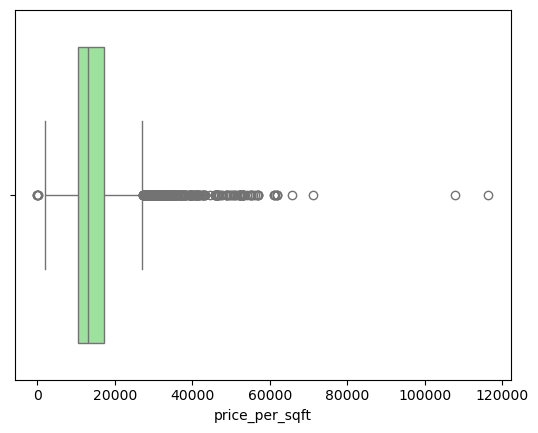

In [45]:
sns.boxplot(x=df["price_per_sqft"], color="lightgreen")

**Price per sqft — Observations**
- Count: 3,118 (missing = 0)  
- Mean: ~15,830; Median: ~13,166  
- IQR: ~10,588 to ~17,129  
- Range: ~27.94 to ~116,421  

**Visuals**
- Histogram: Strong right‑skew with a long high‑price tail.  
- Box plot: Many high‑end outliers; most listings cluster at lower values.


## bedrooms

In [46]:
df["bedrooms"].isnull().sum()

np.int64(97)

<Axes: xlabel='bedrooms'>

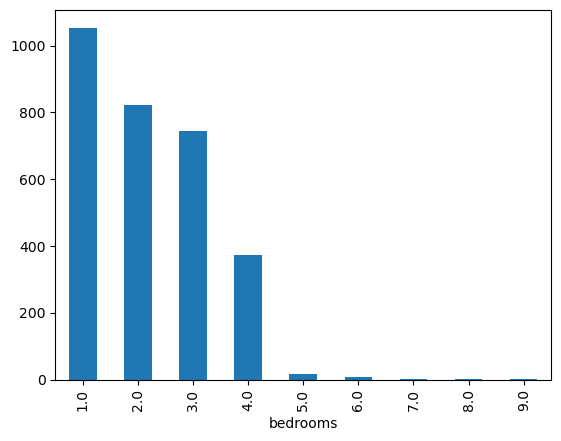

In [47]:
df["bedrooms"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

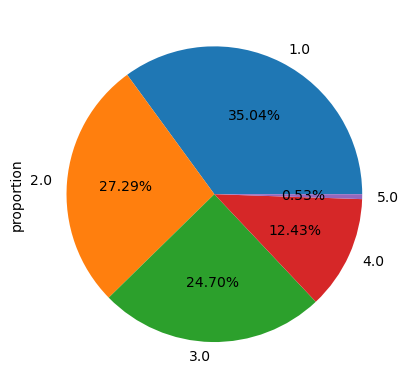

In [48]:
df["bedrooms"].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## bathrooms

In [50]:
df["baths"].isnull().sum()

np.int64(29)

<Axes: xlabel='baths'>

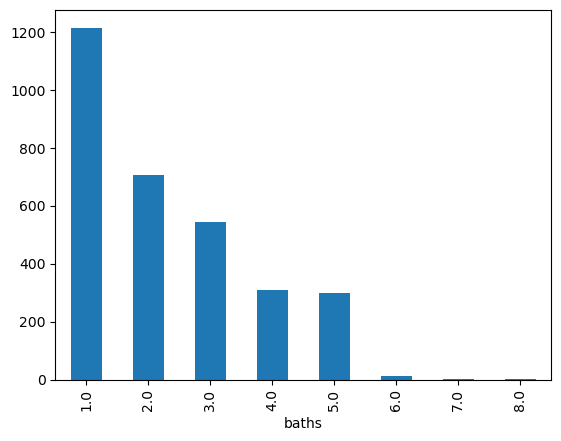

In [51]:
df["baths"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

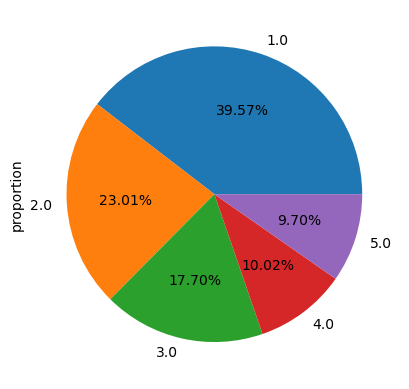

In [52]:
df['baths'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## kitchens

In [53]:
df["kitchens"].isnull().sum()

np.int64(748)

<Axes: xlabel='kitchens'>

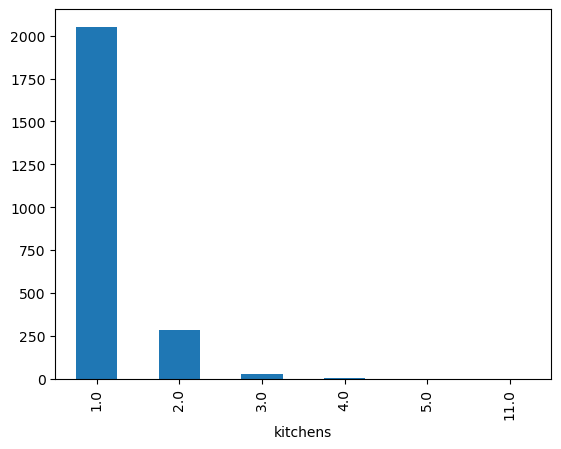

In [54]:
df["kitchens"].value_counts().sort_index().plot(kind="bar")

<Axes: ylabel='proportion'>

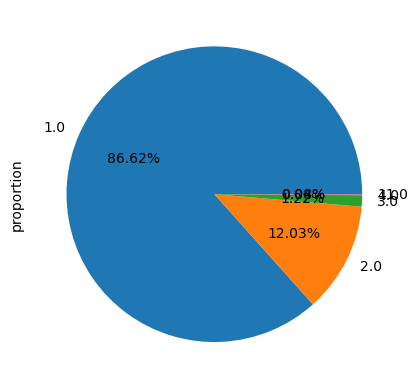

In [55]:
df['kitchens'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## servant_quarters

In [56]:
df["servant_quarters"].isnull().sum()

np.int64(1386)

<Axes: xlabel='servant_quarters'>

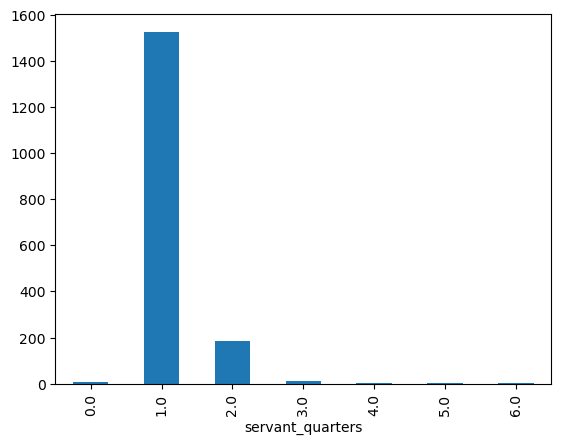

In [57]:
df["servant_quarters"].value_counts().sort_index().plot(kind="bar")

<Axes: ylabel='proportion'>

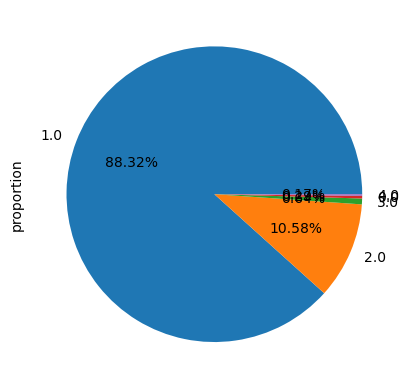

In [58]:
df['servant_quarters'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## store_rooms

In [59]:
df["store_rooms"].isnull().sum()

np.int64(1358)

<Axes: xlabel='store_rooms'>

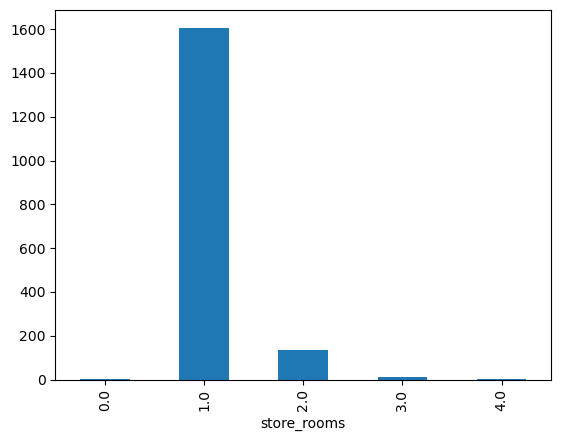

In [60]:
df["store_rooms"].value_counts().sort_index().plot(kind="bar")

<Axes: ylabel='proportion'>

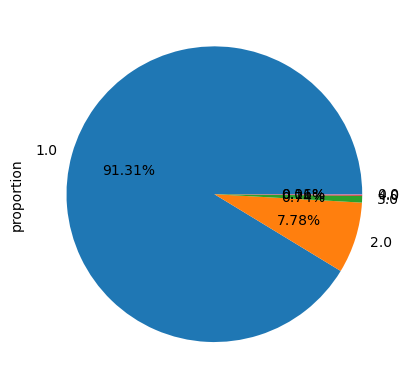

In [61]:
df['store_rooms'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## drawing_room

In [62]:
df["drawing_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='drawing_room'>

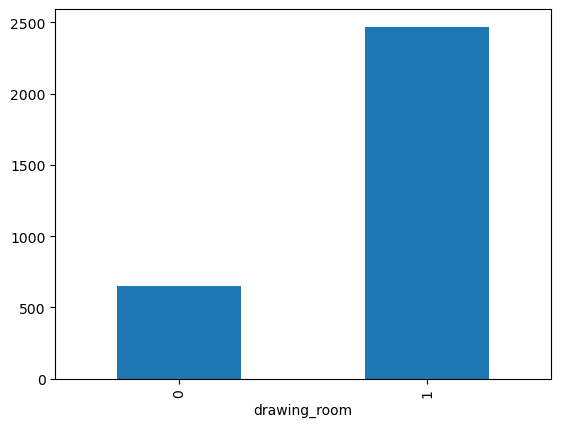

In [63]:
df["drawing_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

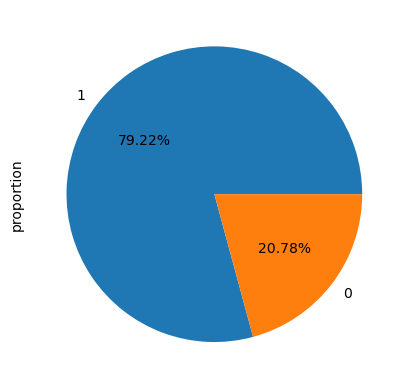

In [ ]:
df['drawing_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## dining_room

In [65]:
df["dining_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='dining_room'>

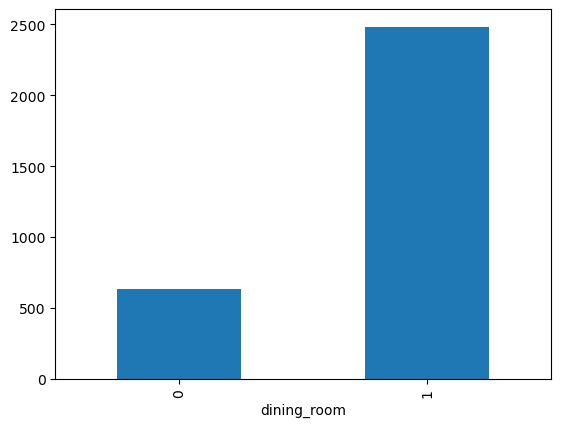

In [66]:
df["dining_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

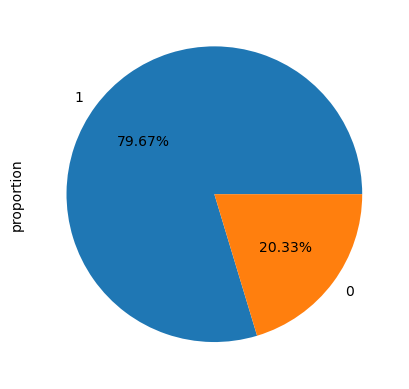

In [67]:
df['dining_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## lounge_or_sitting_room

In [68]:
df["lounge_or_sitting_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='lounge_or_sitting_room'>

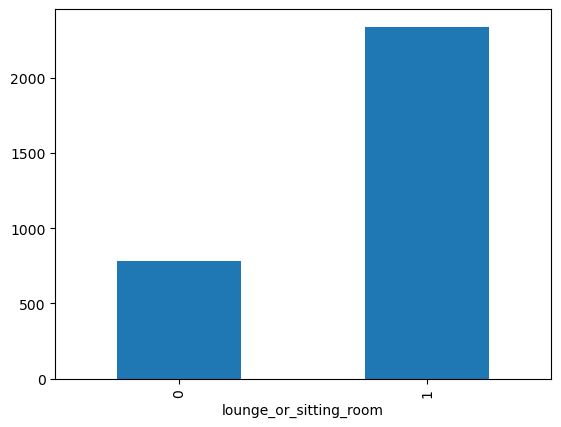

In [69]:
df["lounge_or_sitting_room"].value_counts().sort_index().plot(kind="bar")

<Axes: ylabel='proportion'>

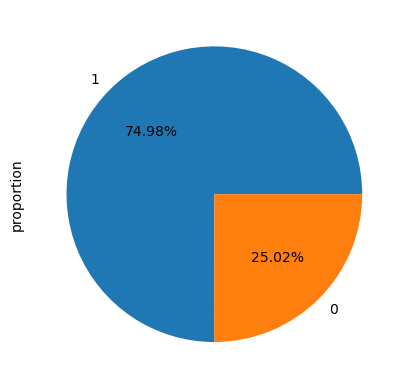

In [70]:
df['lounge_or_sitting_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## laundry_room

In [71]:
df["laundry_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='laundry_room'>

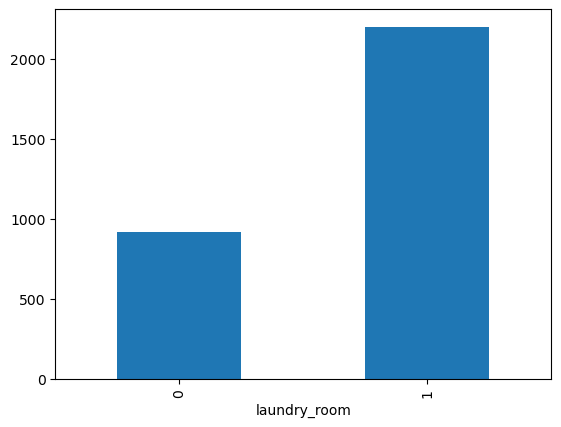

In [72]:
df["laundry_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

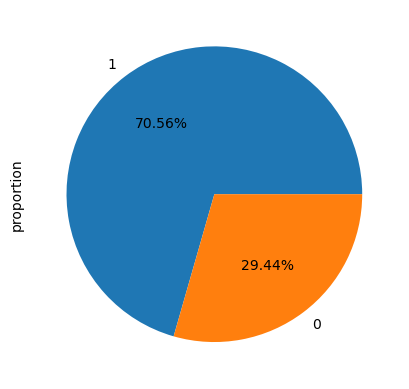

In [73]:
df['laundry_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## study_room

In [74]:
df["study_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='study_room'>

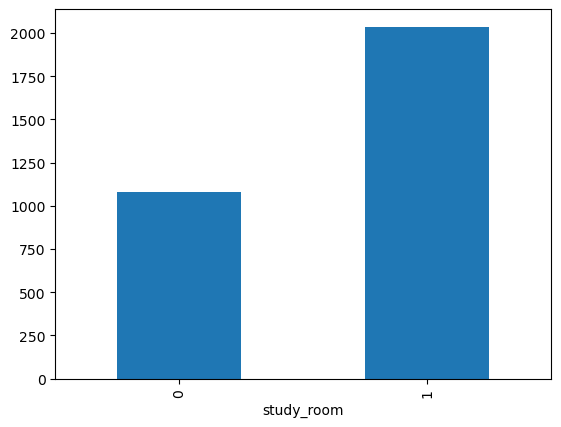

In [75]:
df["study_room"].value_counts().sort_index().plot(kind="bar")

<Axes: ylabel='proportion'>

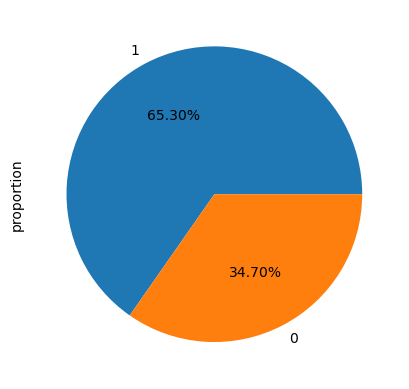

In [76]:
df['study_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## prayer_room

In [77]:
df["prayer_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='prayer_room'>

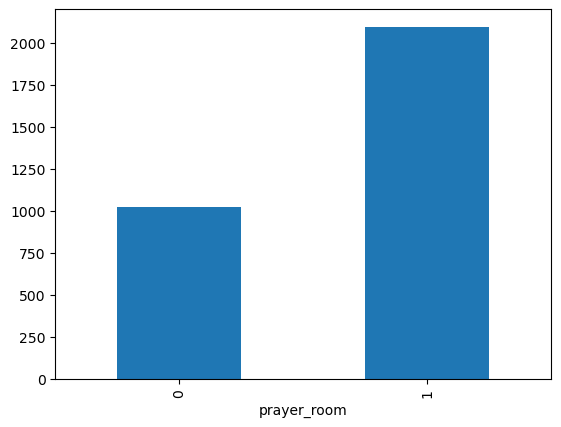

In [78]:
df["prayer_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

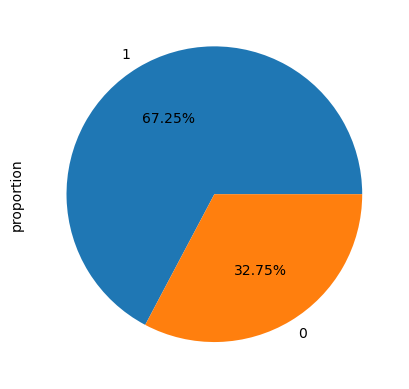

In [79]:
df['prayer_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## powder_room

In [80]:
df["powder_room"].isnull().sum()


np.int64(0)

<Axes: xlabel='powder_room'>

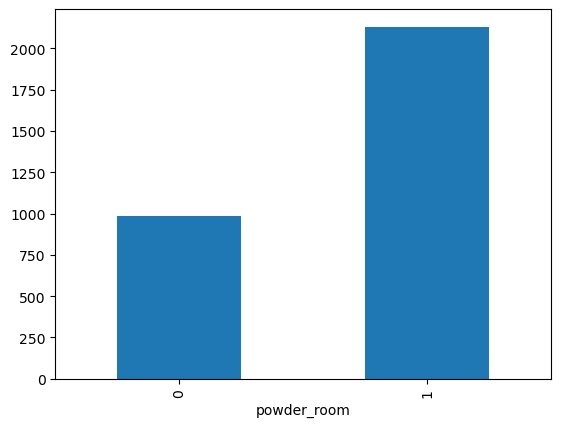

In [81]:
df["powder_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

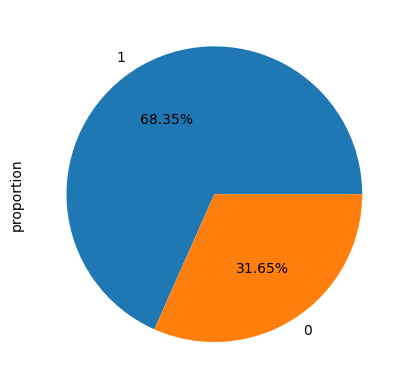

In [82]:
df['powder_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## gym

In [83]:
df["gym"].isnull().sum()


np.int64(0)

<Axes: xlabel='gym'>

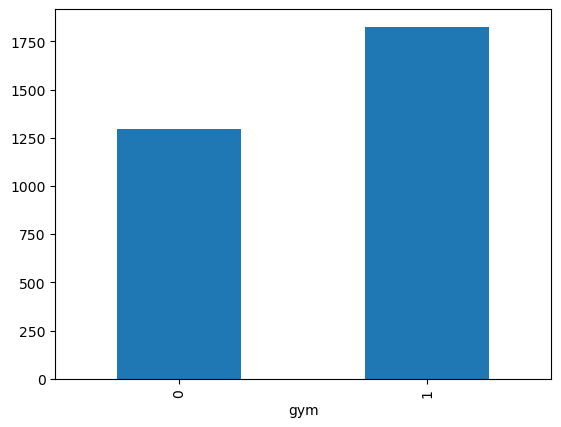

In [84]:
df["gym"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

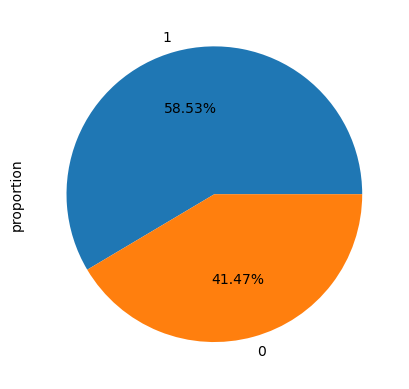

In [85]:
df['gym'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## steam_room

In [86]:
df["steam_room"].isnull().sum()

np.int64(0)

<Axes: xlabel='steam_room'>

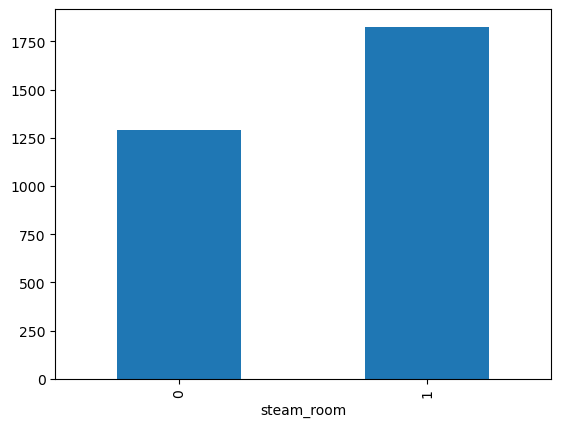

In [87]:
df["steam_room"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

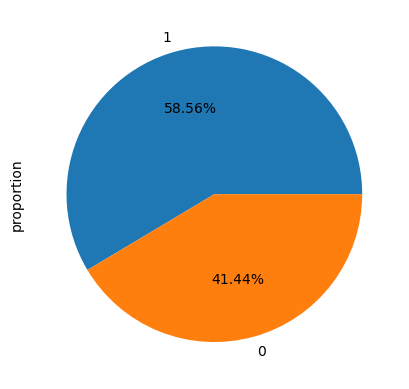

In [88]:
df['steam_room'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## other rooms

In [89]:
df["other_rooms"].isnull().sum()

np.int64(0)

<Axes: xlabel='other_rooms'>

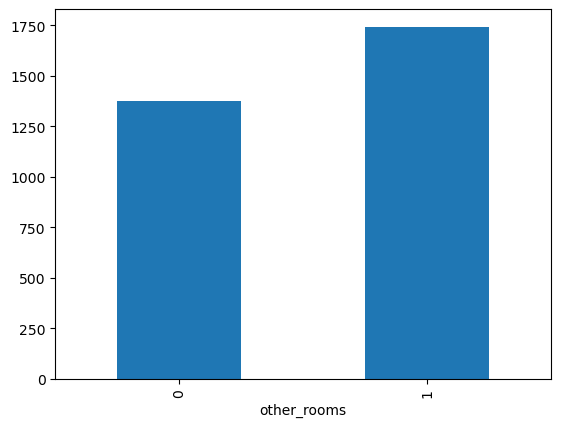

In [90]:
df["other_rooms"].value_counts().sort_index().plot(kind="bar")


<Axes: ylabel='proportion'>

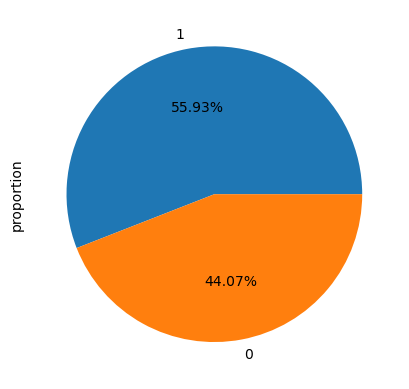

In [91]:
df['other_rooms'].value_counts(normalize=True).head().plot(kind="pie", autopct="%0.2f%%")

## floor num

In [95]:
df1=pd.read_csv("lahore_flats_feature_engineered.csv")

In [96]:
df['floor']=df1['floor']

In [97]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'built_year', 'link',
       'floors_in_building', 'price', 'area', 'area_sqft', 'servant_quarters',
       'kitchens', 'store_rooms', 'price_per_sqft', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor'],
      dtype='object')

In [98]:
df['floor'].isnull().sum()


np.int64(1142)

In [221]:
df['floor_number'].describe()

count    1073.000000
mean        8.137931
std        72.150105
min         1.000000
25%         1.000000
50%         4.000000
75%         7.000000
max      2018.000000
Name: floor_number, dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '10'),
  Text(3, 0, '11'),
  Text(4, 0, '12'),
  Text(5, 0, '13'),
  Text(6, 0, '14'),
  Text(7, 0, '15'),
  Text(8, 0, '16'),
  Text(9, 0, '17'),
  Text(10, 0, '18'),
  Text(11, 0, '19'),
  Text(12, 0, '2'),
  Text(13, 0, '20'),
  Text(14, 0, '2018'),
  Text(15, 0, '21'),
  Text(16, 0, '22'),
  Text(17, 0, '23'),
  Text(18, 0, '25'),
  Text(19, 0, '27'),
  Text(20, 0, '3'),
  Text(21, 0, '30'),
  Text(22, 0, '32'),
  Text(23, 0, '33'),
  Text(24, 0, '35'),
  Text(25, 0, '37'),
  Text(26, 0, '4'),
  Text(27, 0, '5'),
  Text(28, 0, '6'),
  Text(29, 0, '7'),
  Text(30, 0, '8'),
  Text(31, 0, '9'),
  Text(32, 0, 'TRUE')])

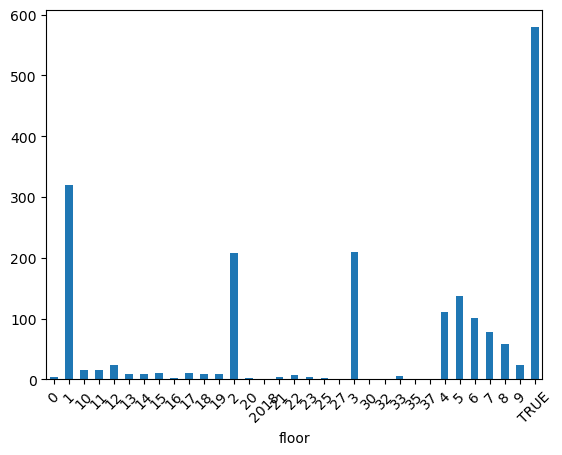

In [100]:
df["floor"].value_counts().sort_index().plot(kind="bar")
plt.xticks(rotation=45)

<Axes: xlabel='floor'>

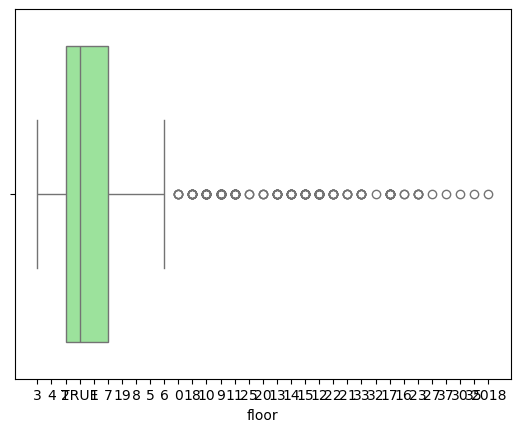

In [101]:
sns.boxplot(x=df["floor"], color="lightgreen")


- **Missingness:** 1,142 missing values; only 1,073 valid floor entries.  
- **Typical floors:** Median = 4; 75% of listings are at floor ≤ 7 (mostly low‑rise).  
- **Outliers:** Max = 2018 indicates clear data errors and inflates the tail.  
- **Box plot:** Strong right tail with a few extreme points; most values cluster at low floors.


## built_year

In [102]:
df['built_year'].isnull().sum()

np.int64(847)

In [106]:
dict(df['built_year'].value_counts())

{np.int64(2025): np.int64(719),
 np.int64(2024): np.int64(315),
 np.int64(2026): np.int64(251),
 np.int64(2023): np.int64(173),
 np.int64(2022): np.int64(124),
 np.int64(2027): np.int64(89),
 np.int64(2018): np.int64(82),
 np.int64(2020): np.int64(81),
 np.int64(2021): np.int64(67),
 np.int64(2028): np.int64(66),
 np.int64(2029): np.int64(65),
 np.int64(2015): np.int64(42),
 np.int64(2017): np.int64(38),
 np.int64(2019): np.int64(33),
 np.int64(2016): np.int64(28),
 np.int64(2010): np.int64(17),
 np.int64(2030): np.int64(13),
 np.int64(2000): np.int64(10),
 np.int64(2005): np.int64(6),
 np.int64(2011): np.int64(4),
 np.int64(1992): np.int64(4),
 np.int64(2014): np.int64(4),
 np.int64(1990): np.int64(4),
 np.int64(2009): np.int64(3),
 np.int64(1985): np.int64(3),
 np.int64(2001): np.int64(3),
 np.int64(2004): np.int64(3),
 np.int64(1986): np.int64(3),
 np.int64(2012): np.int64(3),
 np.int64(2002): np.int64(3),
 np.int64(1994): np.int64(2),
 np.int64(2003): np.int64(2),
 np.int64(1999): 

In [105]:
df["built_year"] = df["built_year"].astype("Int64")

In [107]:
import numpy as np
import pandas as pd

current_year = 2026  # set as needed

def classify_year(y):
    if pd.isna(y):
        return "Undefined"
    if y > current_year:
        return "Under construction"
    age = current_year - y
    if age <= 3:
        return "New Property"
    if age <= 10:
        return "Relatively New"
    if age <= 20:
        return "Moderately Old"
    return "Old Property"

df["built_year_category"] = df["built_year"].apply(classify_year)

In [108]:
df["built_year_category"].value_counts()

built_year_category
New Property          1458
Undefined              847
Relatively New         453
Under construction     233
Moderately Old          77
Old Property            50
Name: count, dtype: int64

In [109]:
df = df.rename(columns={"built_year_category": "agePossession"})

In [110]:
df = df.drop(columns=["built_year"])

In [111]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'link',
       'floors_in_building', 'price', 'area', 'area_sqft', 'servant_quarters',
       'kitchens', 'store_rooms', 'price_per_sqft', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

## area

In [112]:
df["area_sqft"].isnull().sum()

np.int64(0)

In [113]:
df["area_sqft"].describe()


count      3118.000000
mean       1871.365234
std        9467.696829
min         108.800000
25%         598.400000
50%        1115.200000
75%        2720.000000
max      326400.000000
Name: area_sqft, dtype: float64

<Axes: xlabel='area_sqft', ylabel='Count'>

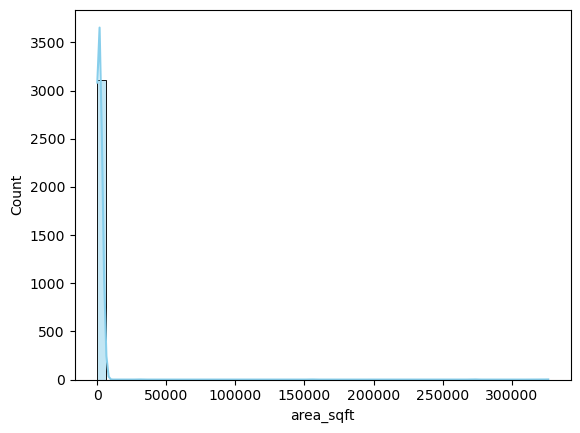

In [114]:
sns.histplot(df["area_sqft"].dropna(), bins=50, color="skyblue", kde=True)


<Axes: xlabel='area_sqft'>

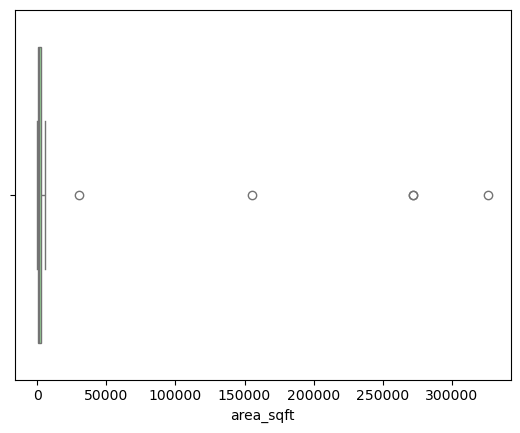

In [115]:
sns.boxplot(x=df["area_sqft"].dropna(), color="lightgreen")

**Area (sqft) — Observations**
- Missing values: 0  
- IQR: ~598.4 to ~2,720 sqft (most listings fall in this range).  
- Median: ~1,115 sqft; Mean: ~1,871 sqft → right‑skewed.  
- Extreme outliers push the max to ~326,400 sqft.


## marla


In [117]:
df["area"].isnull().sum()


np.int64(0)

In [235]:
df["marla"].describe()


count    2463.000000
mean        6.205197
std         3.976709
min         0.400000
25%         2.400000
50%         5.000000
75%        10.000000
max        28.500000
Name: marla, dtype: float64

<Axes: xlabel='area', ylabel='Count'>

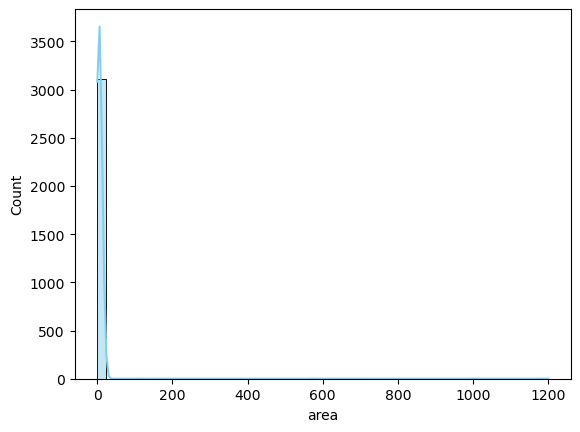

In [119]:
sns.histplot(df["area"].dropna(), bins=50, color="skyblue", kde=True)


<Axes: xlabel='area'>

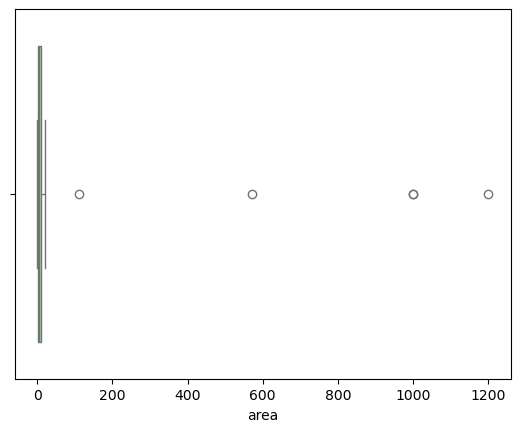

In [120]:
sns.boxplot(x=df["area"].dropna(), color="lightgreen")


## luxury_score

In [121]:
df["luxury_score"].isnull().sum()

np.int64(0)

In [122]:
df["luxury_score"].describe()


count    3118.000000
mean      141.720013
std        46.583240
min         0.000000
25%       121.000000
50%       158.000000
75%       176.000000
max       187.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

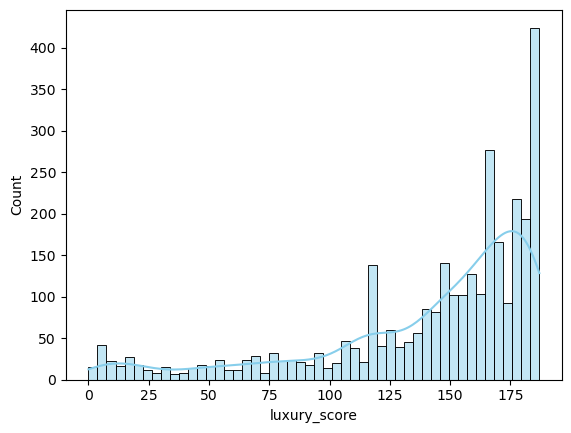

In [123]:
sns.histplot(df["luxury_score"], bins=50, color="skyblue", kde=True)

<Axes: xlabel='luxury_score'>

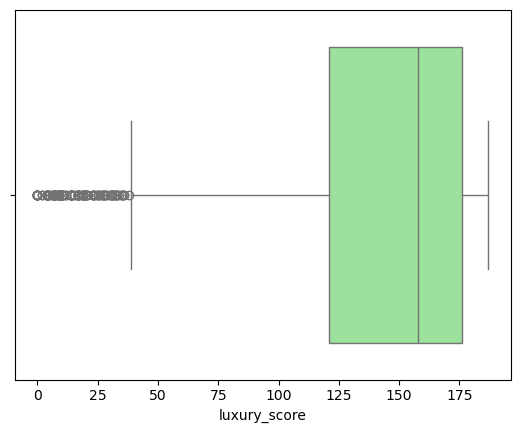

In [124]:
sns.boxplot(x=df["luxury_score"], color="lightgreen")


## Pandas profiling

**Pandas Profiling** (now `ydata-profiling`) is an automated EDA tool that generates an HTML report with summary stats, distributions, missing values, correlations, and sample data. It gives a quick overview without writing manual plots.


In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

# df = pd.read_csv("lahore_flats_feature_engineered.csv").drop_duplicates()

profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
profile.to_file("output_report.html")

c:\Users\zeeshan_ahmed\miniconda3\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 17.24it/s]


In [126]:
df.to_csv("flats_data_unianalysis.csv", index=False)